# Dataset
We will explore this dataset: https://archive.ics.uci.edu/ml/datasets/EEG+Eye+State#

> All data is from one continuous EEG measurement with the Emotiv EEG Neuroheadset. The duration of the measurement was 117 seconds. The eye state was detected via a camera during the EEG measurement and added later manually to the file after analysing the video frames. '1' indicates the eye-closed and '0' the eye-open state. All values are in chronological order with the first measured value at the top of the data.

In [1]:
from pathlib import Path

from mads_datasets import datatools

data_dir = Path.home() / ".cache/mads_datasets/egg"
if not data_dir.exists():
    data_dir.mkdir(parents=True)

filename = "EGG.arff"
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00264/EEG%20Eye%20State.arff"
datatools.get_file(data_dir=data_dir, filename=filename, url=url, unzip=False)
datapath = data_dir / filename

2026-06-16 17:31:45.762 | INFO     | mads_datasets.datatools:get_file:95 - File /Users/vince/.cache/mads_datasets/egg/EGG.arff already exists, skip download


You can load the arff file with scipy

In [2]:
from scipy.io import arff

data = arff.loadarff(datapath)

The data is a tuple of a description and observations

In [3]:
len(data), type(data)

(2, tuple)

Description

In [4]:
data[1]

Dataset: EEG_DATA
	AF3's type is numeric
	F7's type is numeric
	F3's type is numeric
	FC5's type is numeric
	T7's type is numeric
	P7's type is numeric
	O1's type is numeric
	O2's type is numeric
	P8's type is numeric
	T8's type is numeric
	FC6's type is numeric
	F4's type is numeric
	F8's type is numeric
	AF4's type is numeric
	eyeDetection's type is nominal, range is ('0', '1')

There are about 15k observations

In [5]:
len(data[0])

14980

The observations are tuples of floats and a byte as label

In [6]:
data[0][0]

np.void((4329.23, 4009.23, 4289.23, 4148.21, 4350.26, 4586.15, 4096.92, 4641.03, 4222.05, 4238.46, 4211.28, 4280.51, 4635.9, 4393.85, b'0'), dtype=[('AF3', '<f8'), ('F7', '<f8'), ('F3', '<f8'), ('FC5', '<f8'), ('T7', '<f8'), ('P7', '<f8'), ('O1', '<f8'), ('O2', '<f8'), ('P8', '<f8'), ('T8', '<f8'), ('FC6', '<f8'), ('F4', '<f8'), ('F8', '<f8'), ('AF4', '<f8'), ('eyeDetection', 'S1')])

In [7]:
for x in data[0][0]:
    print(type(x))

<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.bytes_'>


Let's cast the byte ot int

In [8]:
labels = []
for x in data[0]:
    labels.append(int(x[14]))

In [9]:
import numpy as np

np.array(labels).mean()

np.float64(0.4487983978638184)

About 45% of the data has closed eyes.

# Excercises 1
- download the data to a given path. You can use the datatools.py method get_file for that, and wrap it with the prerpocessing.
- build a custom Dataset that yields a $X, y$ tuple of tensors. $X$ should be sequential in time. Remember: a dataset should implement `__get_item__` and `__len__`.
- You can try to implement your own datafactory. Study all the examples in `mads_datasets` sourcecode.
- note that you could model this as both a classification task, but also as a sequence-to-sequence task! For this excercise, make it a classification task with consecutive 0s or 1s only.
- Note that, for a training task, a seq2seq model will probably be more realistic. However, the classification is a nice excercise because it is harder to set up.
- figure out what the length distribution is of your dataset: how many timestamps do you have for every consecutive sequence of 0s and 1s? On average, median, min, max?
- create a dataloader that yields timeseries with (batch, sequence_lenght). You can implement: windowed, padded and batched.
    1. yielding a windowed item should be the easy level
    2. yielding windowed and padded is medium level 
    3. yielding windowed, padded and batched is expert level, because the windowing will cause the timeseries to have different sizes. You will need to buffer before you can yield a batch.

- check if your dataloader works:
    - it should not give errors because it runs out of data! Either let is stop by itself, or run forever.
    - batchsize should be consistent (in case 1 and 2, batchsize is 1)
    - sequence length is allowed to vary

# Excercise 2
- build a Dataset that yields sequences of X, y. This time, y is a sequence and can contain both 0s and 1s
- create a Dataloader with this
- Test appropriate architectures (RNN, Attention)
- for the loss, note that you will need a BCELoss instead of a CrossEntroyLoss

# Exercise 1 — Classification on consecutive sequences

## 1a. Parse the data into features and labels

In [10]:
from pathlib import Path
from typing import Iterator

import numpy as np
import torch
import torch.nn as nn
from loguru import logger
from torch import Tensor, optim
from torch.nn.utils.rnn import pad_sequence

# Parse features and labels from ARFF data
features = np.array([list(row)[:14] for row in data[0]], dtype=np.float32)
labels = np.array([int(row[14]) for row in data[0]], dtype=np.int64)

logger.info(f"Features shape: {features.shape}")
logger.info(f"Labels shape: {labels.shape}")
logger.info(f"Label distribution: {np.mean(labels):.3f} (fraction eye-closed)")

2026-06-16 17:31:46.431 | INFO     | __main__:<module>:14 - Features shape: (14980, 14)


2026-06-16 17:31:46.431 | INFO     | __main__:<module>:15 - Labels shape: (14980,)


2026-06-16 17:31:46.432 | INFO     | __main__:<module>:16 - Label distribution: 0.449 (fraction eye-closed)


## 1b. Split into consecutive segments and build a Dataset

Split the continuous timeseries into segments where the label stays constant (all 0s or all 1s). Each segment becomes one sample with a single classification label.

In [11]:
from torch.utils.data import Dataset


def split_into_segments(
    features: np.ndarray, labels: np.ndarray
) -> list[tuple[np.ndarray, int]]:
    """Split continuous timeseries into segments of consecutive identical labels."""
    segments: list[tuple[np.ndarray, int]] = []
    start = 0
    for i in range(1, len(labels)):
        if labels[i] != labels[start]:
            segment_features = features[start:i]
            segment_label = int(labels[start])
            segments.append((segment_features, segment_label))
            start = i
    # Add the last segment
    segments.append((features[start:], int(labels[start])))
    return segments


segments = split_into_segments(features, labels)
logger.info(f"Number of segments: {len(segments)}")


class EEGClassificationDataset(Dataset):
    """Dataset that yields (X, y) where X is a segment of EEG features and y is the label."""

    def __init__(self, segments: list[tuple[np.ndarray, int]]) -> None:
        self.segments = segments

    def __len__(self) -> int:
        return len(self.segments)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        feat, label = self.segments[idx]
        X = torch.tensor(feat, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.long)
        return X, y


dataset = EEGClassificationDataset(segments)
X_sample, y_sample = dataset[0]
logger.info(f"Sample X shape: {X_sample.shape}, y: {y_sample}")

2026-06-16 17:31:46.436 | INFO     | __main__:<module>:22 - Number of segments: 24


2026-06-16 17:31:46.437 | INFO     | __main__:<module>:43 - Sample X shape: torch.Size([188, 14]), y: 0


## 1c. Analyse length distribution

Mean length:   624.2
Median length: 501.5
Min length:    21
Max length:    2401
Std length:    586.8


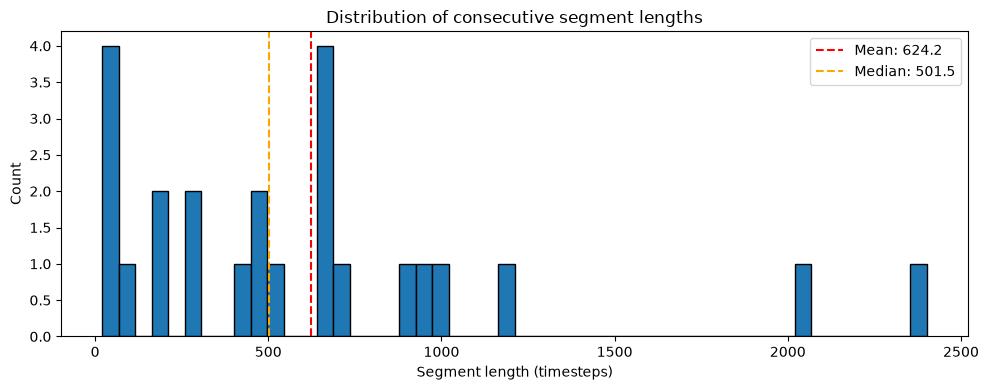

In [12]:
import matplotlib.pyplot as plt

%matplotlib inline

segment_lengths = np.array([seg[0].shape[0] for seg in segments])

print(f"Mean length:   {segment_lengths.mean():.1f}")
print(f"Median length: {np.median(segment_lengths):.1f}")
print(f"Min length:    {segment_lengths.min()}")
print(f"Max length:    {segment_lengths.max()}")
print(f"Std length:    {segment_lengths.std():.1f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(segment_lengths, bins=50, edgecolor="black")
ax.set_xlabel("Segment length (timesteps)")
ax.set_ylabel("Count")
ax.set_title("Distribution of consecutive segment lengths")
ax.axvline(segment_lengths.mean(), color="red", linestyle="--", label=f"Mean: {segment_lengths.mean():.1f}")
_med = float(np.median(segment_lengths))
ax.axvline(_med, color="orange", linestyle="--", label=f"Median: {_med:.1f}")
ax.legend()
plt.tight_layout()
plt.show()

## 1d. DataLoaders — Three difficulty levels

### Level 1 (Easy): Windowed — yield one sequence at a time, batchsize=1

In [13]:
class WindowedStreamer:
    """Level 1: yields one (X, y) at a time, unbatched. Loops forever."""

    def __init__(self, dataset: EEGClassificationDataset) -> None:
        self.dataset = dataset

    def __len__(self) -> int:
        return len(self.dataset)

    def stream(self) -> Iterator[tuple[Tensor, Tensor]]:
        while True:
            for i in range(len(self.dataset)):
                X, y = self.dataset[i]
                # Add batch dimension: (1, seq_len, 14)
                yield X.unsqueeze(0), y.unsqueeze(0)


# Test level 1
windowed = WindowedStreamer(dataset)
streamer = windowed.stream()
for i in range(3):
    X, y = next(streamer)
    print(f"Batch {i}: X shape={X.shape}, y shape={y.shape}, y={y.item()}")

Batch 0: X shape=torch.Size([1, 188, 14]), y shape=torch.Size([1]), y=0
Batch 1: X shape=torch.Size([1, 683, 14]), y shape=torch.Size([1]), y=1
Batch 2: X shape=torch.Size([1, 465, 14]), y shape=torch.Size([1]), y=0


### Level 2 (Medium): Windowed + Padded — pad to same length, batchsize=1

In [14]:
class PaddedStreamer:
    """Level 2: yields one padded (X, y) at a time. All sequences padded to max_len."""

    def __init__(self, dataset: EEGClassificationDataset, max_len: int) -> None:
        self.dataset = dataset
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.dataset)

    def _pad(self, X: Tensor) -> Tensor:
        """Pad or truncate sequence to max_len."""
        seq_len = X.shape[0]
        if seq_len >= self.max_len:
            return X[: self.max_len]
        padding = torch.zeros(self.max_len - seq_len, X.shape[1])
        return torch.cat([X, padding], dim=0)

    def stream(self) -> Iterator[tuple[Tensor, Tensor]]:
        while True:
            for i in range(len(self.dataset)):
                X, y = self.dataset[i]
                X_padded = self._pad(X)
                yield X_padded.unsqueeze(0), y.unsqueeze(0)


# Use median as a reasonable pad length
max_len = int(np.median(segment_lengths))
padded = PaddedStreamer(dataset, max_len=max_len)
streamer = padded.stream()
for i in range(3):
    X, y = next(streamer)
    print(f"Batch {i}: X shape={X.shape}, y shape={y.shape}, y={y.item()}")

Batch 0: X shape=torch.Size([1, 501, 14]), y shape=torch.Size([1]), y=0
Batch 1: X shape=torch.Size([1, 501, 14]), y shape=torch.Size([1]), y=1
Batch 2: X shape=torch.Size([1, 501, 14]), y shape=torch.Size([1]), y=0


### Level 3 (Expert): Windowed + Padded + Batched — buffer sequences and pad within batch

In [15]:
class BatchedPaddedStreamer:
    """Level 3: buffer sequences, pad within batch to max length in that batch, yield proper batches.

    NOTE: this EEG recording only contains ~24 consecutive-label segments, which is
    fewer than a full batch. A streamer that *only* yields full batches would loop
    forever without ever yielding (and hang the kernel), so we also yield the final
    partial batch. That keeps the streamer usable for datasets smaller than batchsize.
    """

    def __init__(self, dataset: EEGClassificationDataset, batchsize: int) -> None:
        self.dataset = dataset
        self.batchsize = batchsize

    def __len__(self) -> int:
        # ceil, min 1: a trailing partial batch still counts (dataset can be < batchsize)
        return max(1, -(-len(self.dataset) // self.batchsize))

    def _make_batch(self, buffer_X: list[Tensor], buffer_y: list[Tensor]) -> tuple[Tensor, Tensor]:
        X_padded = pad_sequence(buffer_X, batch_first=True, padding_value=0.0)
        y_batch = torch.stack(buffer_y)
        return X_padded, y_batch

    def stream(self) -> Iterator[tuple[Tensor, Tensor]]:
        while True:
            buffer_X: list[Tensor] = []
            buffer_y: list[Tensor] = []
            for i in range(len(self.dataset)):
                X, y = self.dataset[i]
                buffer_X.append(X)
                buffer_y.append(y)
                if len(buffer_X) == self.batchsize:
                    yield self._make_batch(buffer_X, buffer_y)
                    buffer_X = []
                    buffer_y = []
            # yield the trailing partial batch so small datasets still produce a batch
            if buffer_X:
                yield self._make_batch(buffer_X, buffer_y)


# Test level 3
batched = BatchedPaddedStreamer(dataset, batchsize=32)
streamer = batched.stream()
for i in range(3):
    X, y = next(streamer)
    print(f"Batch {i}: X shape={X.shape}, y shape={y.shape}")

Batch 0: X shape=torch.Size([24, 2401, 14]), y shape=torch.Size([24])
Batch 1: X shape=torch.Size([24, 2401, 14]), y shape=torch.Size([24])
Batch 2: X shape=torch.Size([24, 2401, 14]), y shape=torch.Size([24])


## 1e. Train a classifier with the expert-level dataloader

We use `GRUmodel` from `mltrainer.rnn_models` with the batched padded streamer. We split segments into train/valid sets first.

In [16]:
from mltrainer import ReportTypes, Trainer, TrainerSettings, metrics
from mltrainer.rnn_models import GRUmodel, ModelConfig

# Train/valid split (80/20) on segments
np.random.seed(42)
indices = np.random.permutation(len(segments))
split = int(0.8 * len(segments))
train_segments = [segments[i] for i in indices[:split]]
valid_segments = [segments[i] for i in indices[split:]]

train_dataset = EEGClassificationDataset(train_segments)
valid_dataset = EEGClassificationDataset(valid_segments)

batchsize = 32
train_streamer = BatchedPaddedStreamer(train_dataset, batchsize=batchsize)
valid_streamer = BatchedPaddedStreamer(valid_dataset, batchsize=batchsize)

logger.info(f"Train segments: {len(train_dataset)}, batches: {len(train_streamer)}")
logger.info(f"Valid segments: {len(valid_dataset)}, batches: {len(valid_streamer)}")

2026-06-16 17:31:48.165 | INFO     | __main__:<module>:18 - Train segments: 19, batches: 1


2026-06-16 17:31:48.165 | INFO     | __main__:<module>:19 - Valid segments: 5, batches: 1


In [17]:
# Device selection
# NOTE: on this M5 the mps (Metal/GPU) backend crashes the Python kernel during
# training (it died mid-run), so we force CPU. Change this line for a CUDA machine.
device = "cpu"
print(f"Using device: {device}")

Using device: cpu


In [18]:
# Classification model config: 14 EEG features, 2 classes (eye open/closed)
config = ModelConfig(
    input_size=14,
    hidden_size=64,
    num_layers=2,
    output_size=2,
    dropout=0.1,
)

accuracy = metrics.Accuracy()
loss_fn = nn.CrossEntropyLoss()
log_dir = Path("logs/eeg_classification/").resolve()

settings = TrainerSettings(
    epochs=10,
    metrics=[accuracy],
    logdir=log_dir,
    train_steps=len(train_streamer),
    valid_steps=len(valid_streamer),
    reporttypes=[ReportTypes.TENSORBOARD],
    scheduler_kwargs={"factor": 0.5, "patience": 3},
)

model = GRUmodel(config)
logger.info(f"Model: {model}")

trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optim.Adam,
    traindataloader=train_streamer.stream(),
    validdataloader=valid_streamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
    device=device,
)
trainer.loop()

2026-06-16 17:31:48.171 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/vince/Documents/HAN/MADS-ML-Vincent/notebooks/5_attention/logs/eeg_classification


2026-06-16 17:31:48.172 | INFO     | __main__:<module>:25 - Model: GRUmodel(
  (rnn): GRU(14, 64, num_layers=2, batch_first=True, dropout=0.1)
  (linear): Linear(in_features=64, out_features=2, bias=True)
)


2026-06-16 17:31:48.172 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/vince/Documents/HAN/MADS-ML-Vincent/notebooks/5_attention/logs/eeg_classification/20260616-173148


2026-06-16 17:31:48.582 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/10 [00:00<?, ?it/s]

...

100%|██████████| 1/1 [00:00<00:00,  3.85it/s]


2026-06-16 17:31:51.783 | INFO     | mltrainer.trainer:report:209 - Epoch 9 train 0.6622 test 0.9172 metric ['0.4000']


2026-06-16 17:31:51.784 | INFO     | mltrainer.trainer:__call__:252 - best loss: 0.7042, current loss 0.9172.Counter 9/10.


100%|██████████| 10/10 [00:03<00:00,  3.29it/s]

100%|██████████| 10/10 [00:03<00:00,  3.17it/s]

# Exercise 2 — Sequence-to-sequence

Build a Dataset where y is also a sequence (can contain both 0s and 1s). Use BCELoss since the output at each timestep is a binary prediction.

## 2a. Seq2seq Dataset

We split the full timeseries into fixed-length windows. Each window has a sequence of labels (y) that can contain both 0s and 1s.

In [19]:
class EEGSeq2SeqDataset(Dataset):
    """Dataset that yields (X, y) where both are sequences.

    X: (window_size, 14) EEG features
    y: (window_size,) binary labels per timestep
    """

    def __init__(self, features: np.ndarray, labels: np.ndarray, window_size: int = 64) -> None:
        self.features = features
        self.labels = labels
        self.window_size = window_size
        # Number of non-overlapping windows
        self.n_windows = len(features) // window_size

    def __len__(self) -> int:
        return self.n_windows

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        start = idx * self.window_size
        end = start + self.window_size
        X = torch.tensor(self.features[start:end], dtype=torch.float32)
        y = torch.tensor(self.labels[start:end], dtype=torch.float32)
        return X, y


# Split 80/20 by index in the timeseries
split_idx = int(0.8 * len(features))
window_size = 64

train_seq_dataset = EEGSeq2SeqDataset(features[:split_idx], labels[:split_idx], window_size=window_size)
valid_seq_dataset = EEGSeq2SeqDataset(features[split_idx:], labels[split_idx:], window_size=window_size)

logger.info(f"Train windows: {len(train_seq_dataset)}, Valid windows: {len(valid_seq_dataset)}")

# Check a sample
X_s, y_s = train_seq_dataset[0]
print(f"Sample X shape: {X_s.shape}, y shape: {y_s.shape}")
print(f"Sample y values: {y_s[:10]}")

2026-06-16 17:31:51.789 | INFO     | __main__:<module>:33 - Train windows: 187, Valid windows: 46


Sample X shape: torch.Size([64, 14]), y shape: torch.Size([64])
Sample y values: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## 2b. Seq2seq DataLoader

Fixed window size means all sequences have the same length, so we can use a simple batched streamer.

In [20]:
class Seq2SeqStreamer:
    """Streamer for fixed-size seq2seq windows. Loops forever."""

    def __init__(self, dataset: EEGSeq2SeqDataset, batchsize: int) -> None:
        self.dataset = dataset
        self.batchsize = batchsize

    def __len__(self) -> int:
        return len(self.dataset) // self.batchsize

    def stream(self) -> Iterator[tuple[Tensor, Tensor]]:
        while True:
            indices = np.random.permutation(len(self.dataset))
            buffer_X: list[Tensor] = []
            buffer_y: list[Tensor] = []
            for i in indices:
                X, y = self.dataset[int(i)]
                buffer_X.append(X)
                buffer_y.append(y)
                if len(buffer_X) == self.batchsize:
                    yield torch.stack(buffer_X), torch.stack(buffer_y)
                    buffer_X = []
                    buffer_y = []


batchsize = 32
train_seq_streamer = Seq2SeqStreamer(train_seq_dataset, batchsize=batchsize)
valid_seq_streamer = Seq2SeqStreamer(valid_seq_dataset, batchsize=batchsize)

logger.info(f"Train batches: {len(train_seq_streamer)}, Valid batches: {len(valid_seq_streamer)}")

# Test
streamer = train_seq_streamer.stream()
X_batch, y_batch = next(streamer)
print(f"X batch shape: {X_batch.shape}, y batch shape: {y_batch.shape}")

2026-06-16 17:31:51.794 | INFO     | __main__:<module>:30 - Train batches: 5, Valid batches: 1


X batch shape: torch.Size([32, 64, 14]), y batch shape: torch.Size([32, 64])


## 2c. Seq2seq models

We need models that output a prediction at every timestep (not just the last one). We build a GRU seq2seq model and an Attention seq2seq model, both with sigmoid output for BCELoss.

In [21]:
class GRUSeq2Seq(nn.Module):
    """GRU seq2seq model: outputs a prediction at every timestep."""

    def __init__(self, config: ModelConfig) -> None:
        super().__init__()
        self.rnn = nn.GRU(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            dropout=config.dropout,
            batch_first=True,
        )
        self.linear = nn.Linear(config.hidden_size, 1)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.rnn(x)
        # Output at every timestep: (batch, seq_len, hidden) -> (batch, seq_len, 1) -> (batch, seq_len)
        yhat = self.linear(x).squeeze(-1)
        return yhat


class AttentionGRUSeq2Seq(nn.Module):
    """GRU + MultiheadAttention seq2seq model: outputs a prediction at every timestep."""

    def __init__(self, config: ModelConfig) -> None:
        super().__init__()
        self.rnn = nn.GRU(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            dropout=config.dropout,
            batch_first=True,
        )
        self.attention = nn.MultiheadAttention(
            embed_dim=config.hidden_size,
            num_heads=4,
            dropout=config.dropout,
            batch_first=True,
        )
        self.linear = nn.Linear(config.hidden_size, 1)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.rnn(x)
        x, _ = self.attention(x.clone(), x.clone(), x)
        yhat = self.linear(x).squeeze(-1)
        return yhat

## 2d. Binary accuracy metric for seq2seq

The default `Accuracy` uses argmax (for multiclass). For binary seq2seq with BCEWithLogitsLoss we need a metric that thresholds at 0.5 on the sigmoid output.

In [22]:
from mltrainer.metrics import Metric


class BinaryAccuracy(Metric):
    """Binary accuracy for seq2seq: threshold logits at 0, compare with float labels."""

    def _compute(self, y: torch.Tensor, yhat: torch.Tensor) -> torch.Tensor:
        predictions = (yhat > 0).float()  # threshold logits at 0 (sigmoid=0.5)
        return (predictions == y).float().mean()

    def __repr__(self) -> str:
        return "BinaryAccuracy"

## 2e. Train GRU seq2seq model

In [23]:
# Seq2seq config: 14 features in, 1 output per timestep (handled by model)
seq2seq_config = ModelConfig(
    input_size=14,
    hidden_size=64,
    num_layers=2,
    output_size=1,
    dropout=0.1,
)

binary_accuracy = BinaryAccuracy()
# BCEWithLogitsLoss combines sigmoid + BCELoss (more numerically stable)
bce_loss = nn.BCEWithLogitsLoss()

log_dir_seq2seq = Path("logs/eeg_seq2seq/").resolve()

seq2seq_settings = TrainerSettings(
    epochs=10,
    metrics=[binary_accuracy],
    logdir=log_dir_seq2seq,
    train_steps=len(train_seq_streamer),
    valid_steps=len(valid_seq_streamer),
    reporttypes=[ReportTypes.TENSORBOARD],
    scheduler_kwargs={"factor": 0.5, "patience": 3},
)

gru_seq2seq = GRUSeq2Seq(seq2seq_config)
logger.info(f"GRU Seq2Seq model: {gru_seq2seq}")

gru_trainer = Trainer(
    model=gru_seq2seq,
    settings=seq2seq_settings,
    loss_fn=bce_loss,
    optimizer=optim.Adam,
    traindataloader=train_seq_streamer.stream(),
    validdataloader=valid_seq_streamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
    device=device,
)
gru_trainer.loop()

2026-06-16 17:31:51.804 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/vince/Documents/HAN/MADS-ML-Vincent/notebooks/5_attention/logs/eeg_seq2seq


2026-06-16 17:31:51.804 | INFO     | __main__:<module>:27 - GRU Seq2Seq model: GRUSeq2Seq(
  (rnn): GRU(14, 64, num_layers=2, batch_first=True, dropout=0.1)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


2026-06-16 17:31:51.804 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/vince/Documents/HAN/MADS-ML-Vincent/notebooks/5_attention/logs/eeg_seq2seq/20260616-173151


2026-06-16 17:31:51.805 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 124.55it/s]


2026-06-16 17:31:52.265 | INFO     | mltrainer.trainer:report:209 - Epoch 9 train 0.6883 test 0.7514 metric ['0.0820']


2026-06-16 17:31:52.265 | INFO     | mltrainer.trainer:__call__:252 - best loss: 0.7207, current loss 0.7514.Counter 8/10.


100%|██████████| 10/10 [00:00<00:00, 21.75it/s]

## 2f. Train Attention GRU seq2seq model

In [24]:
log_dir_attention = Path("logs/eeg_seq2seq_attention/").resolve()

attention_settings = TrainerSettings(
    epochs=10,
    metrics=[binary_accuracy],
    logdir=log_dir_attention,
    train_steps=len(train_seq_streamer),
    valid_steps=len(valid_seq_streamer),
    reporttypes=[ReportTypes.TENSORBOARD],
    scheduler_kwargs={"factor": 0.5, "patience": 3},
)

attention_seq2seq = AttentionGRUSeq2Seq(seq2seq_config)
logger.info(f"Attention GRU Seq2Seq model: {attention_seq2seq}")

attention_trainer = Trainer(
    model=attention_seq2seq,
    settings=attention_settings,
    loss_fn=bce_loss,
    optimizer=optim.Adam,
    traindataloader=train_seq_streamer.stream(),
    validdataloader=valid_seq_streamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
    device=device,
)
attention_trainer.loop()

2026-06-16 17:31:52.269 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/vince/Documents/HAN/MADS-ML-Vincent/notebooks/5_attention/logs/eeg_seq2seq_attention


2026-06-16 17:31:52.270 | INFO     | __main__:<module>:14 - Attention GRU Seq2Seq model: AttentionGRUSeq2Seq(
  (rnn): GRU(14, 64, num_layers=2, batch_first=True, dropout=0.1)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


2026-06-16 17:31:52.270 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/vince/Documents/HAN/MADS-ML-Vincent/notebooks/5_attention/logs/eeg_seq2seq_attention/20260616-173152


2026-06-16 17:31:52.271 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/10 [00:00<?, ?it/s]

...

100%|██████████| 5/5 [00:00<00:00, 90.06it/s]


2026-06-16 17:31:52.884 | INFO     | mltrainer.trainer:report:209 - Epoch 9 train 0.6909 test 0.7289 metric ['0.1055']


2026-06-16 17:31:52.884 | INFO     | mltrainer.trainer:__call__:252 - best loss: 0.7212, current loss 0.7289.Counter 1/10.


100%|██████████| 10/10 [00:00<00:00, 16.38it/s]

100%|██████████| 10/10 [00:00<00:00, 16.31it/s]